In [37]:
import os
import json
import pickle
import pyreadr

import jax
import jax.numpy as jnp

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


# Configure Display Options
pd.set_option('display.max_colwidth', None)

# Configure Plotting Style
sns.set_theme(style="whitegrid")
%matplotlib inline

# Camera Dataset Analysis

In [38]:
# Define Path to data directory and camera data
data_dir = os.path.join("..", "Data")
json_path = os.path.join(data_dir, "camera_data.json")

# Print the absolute path to verify
print(f"Reading data from: {os.path.abspath(data_dir)}\n")

# Load the data
with open(json_path, 'r') as f:
    camera_data = json.load(f)

# Verify the outer container is a list
print(f"Type of camera_data: {type(camera_data)}") 

# Verify the items inside are dictionaries
first_item = camera_data[0]
print(f"Type of first item:  {type(first_item)}")

# View the keys of that ditionary
print(f"Keys available:      {first_item.keys()}")

Reading data from: c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\PackageComparison\Data

Type of camera_data: <class 'list'>
Type of first item:  <class 'dict'>
Keys available:      dict_keys(['y', 'X'])


In [39]:
# Select the first respondent to analyze the structure
respondent = camera_data[0]
y_sample = respondent['y']
X_sample = respondent['X']

# Total Number of Decision Making Units (N)
n_units = len(camera_data)

# Number of Decisions per Unit (T)
n_decisions_per_unit = len(y_sample)

# Number of Alternatives per Decision (J)
# The design matrix X has (Decisions * Alternatives) rows.
# So: 80 rows / 16 decisions = 5 alternatives.
n_alternatives = int(len(X_sample) / len(y_sample))

# Total Number of Decisions (N * T)
total_decisions = sum(len(resp['y']) for resp in camera_data)

# Print the Summary
print(f"Number of Alternatives per Decision (J):     {n_alternatives}")
print(f"Total number of Decision Making Units (N):   {n_units}")
print(f"Number of Decisions per Unit (T):            {n_decisions_per_unit}")
print(f"Total Number of Decisions (N*T):             {total_decisions}")

Number of Alternatives per Decision (J):     5
Total number of Decision Making Units (N):   332
Number of Decisions per Unit (T):            16
Total Number of Decisions (N*T):             5312


In [40]:
# Extract their components for the first respondent (visual display purposes)
y = respondent['y']           # The choices they made
X = np.array(respondent['X']) # The design matrix

print(f"Number of Decisions (y):    {len(y)}")
print(f"Choices (y):                {y}")
print(f"Shape of Design Matrix (X): {X.shape}")
print(f"First 25 rows of X:\n{X[:25]}")

Number of Decisions (y):    16
Choices (y):                [1, 2, 2, 4, 2, 2, 1, 1, 1, 2, 3, 2, 1, 2, 3, 1]
Shape of Design Matrix (X): (80, 10)
First 25 rows of X:
[[0.   0.   1.   0.   0.   1.   0.   1.   0.   0.79]
 [1.   0.   0.   0.   1.   1.   0.   1.   1.   2.29]
 [0.   0.   0.   1.   0.   0.   0.   0.   1.   1.29]
 [0.   1.   0.   0.   0.   1.   0.   1.   0.   2.79]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   1.   1.   0.   0.   1.   0.   2.79]
 [1.   0.   0.   0.   1.   0.   1.   0.   1.   0.79]
 [0.   1.   0.   0.   1.   0.   1.   0.   1.   1.79]
 [0.   0.   1.   0.   1.   0.   1.   1.   1.   1.29]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   1.   0.   0.   0.   0.   0.   1.   2.29]
 [1.   0.   0.   0.   1.   1.   0.   1.   1.   0.79]
 [0.   1.   0.   0.   1.   0.   0.   1.   1.   1.79]
 [0.   1.   0.   0.   1.   1.   1.   0.   1.   1.29]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   1.   0.   1.   1.   0.   1. 

# Understanding the `bayesm` Camera Dataset Structure

The `camera` dataset is originally stored as a hierarchical list (R), was exported as a Json and is therefore loaded as a list of dictionaries (Python). To analyze it correctly, we must understand how the Choice Vector ($y$) interacts with the Design Matrix ($X$), as well as specific traits in the survey design.

### Key Concepts

1.  **The Design Matrix ($X$):** Contains 80 rows for each respondent.
    * There are **16 Choice Tasks**.
    * Each task has **5 Alternatives**.
    * $16 \times 5 = 80$ rows total.
    * **CRITICAL (Randomization):** The order of brands within each choice task is **randomized (shuffled)**. You cannot assume Row 1 is always Canon. You must check the dummy coded brand feature columns (Indices 0-3) to identify the brand in a specific row.

2.  **The Choice Vector ($y$):** Contains 16 integers from 1 to 5 (e.g., `[1, 2, ...]`).
    * These numbers represent the **row index (position)** of the chosen alternative in the specific block of 5 options.
    * **$y=1$:** The user chose the **1st option** shown in the list (Top Row).
    * **$y=2$:** The user chose the **2nd option** shown in the list (Second Row).
    * ...
    * **$y=5$:** The user chose the **5th option**. Note that while the 5th option is typically the "None" option, the "None" option can technically appear in other rows if a brand is missing.

3.  **Survey Design Peculiarities (Important Findings):**
    * **Partial Profile (Missing Brands):** This is *not* a standard Balanced Design. In some tasks, specific brands are **missing** and were unavailable to choose.
    * **Intra-Brand Competition (Duplicate Brands):** Some choice tasks present the **same brand multiple times** (e.g., Row 1 is Canon, and Row 3 is *also* Canon). This structure allows the model to measure trade-offs within a brand (e.g., a cheap Canon vs. an expensive Canon with additional features) and the estimation of product-feature coefficient distributions.

### How to Decode a Choice
To determine precisely what a user bought, you must follow this 2-step lookup:

1.  **Read $y$:** See which row position was clicked (e.g., `y=1`).
2.  **Read $X$:** Go to that specific row in the $X$ matrix and inspect the brand columns:
    * **Brand Check:** Check which column (0=Canon, 1=Sony, 2=Nikon, 3=Panasonic) is `1`.
    * **None Check:** If **all** brand columns are `0`, the user selected the "None"/"No Purchase" option.

**Example:**
If `y=1` and the first row of $X$ has `Nikon=1`, then the user chose **Nikon**, even though the index is 1.

In [41]:
# SETUP
# Define feature names and expected brand set
features = ["canon", "sony", "nikon", "panasonic", "pixels", "zoom", "video", "swivel", "wifi", "price"]
brands_expected = {"Canon", "Sony", "Nikon", "Panasonic", "None"}


#  HELPER FUNCTIONS
def get_brand_label(row_data):
    """
    Identifies the brand from a single row of the design matrix (dummy columns).
    """
    if row_data[0] == 1: return "Canon"
    if row_data[1] == 1: return "Sony"
    if row_data[2] == 1: return "Nikon"
    if row_data[3] == 1: return "Panasonic"
    
    # Check if all brand columns are 0 (strictly)
    if np.all(row_data[:4] == 0):
        return "None"
    
    return "Unknown"

def analyze_availability(X_matrix):
    """
    Iterates through all 16 tasks to identify missing brands (Partial Profile).
    """
    report_rows = []
    
    for task_idx in range(16):
        # Slice the 5 rows for this task
        start_row = task_idx * 5
        end_row = start_row + 5
        task_block = X_matrix[start_row:end_row]
        
        # Identify content of each row in this block
        present_in_task = set()
        row_descriptions = []
        
        for row in task_block:
            label = get_brand_label(row)
            present_in_task.add(label)
            row_descriptions.append(label)

        # Check for Missing Brands
        missing_items = brands_expected - present_in_task
        is_complete = len(missing_items) == 0
        
        report_rows.append({
            "Task_ID": task_idx + 1,
            "Is_Complete": is_complete,
            "Missing_Brands": list(missing_items) if missing_items else "Full Set",
            "Row_Structure": row_descriptions
        })

    return pd.DataFrame(report_rows)

def display_task_details(X_matrix, y_vector, task_idx, title_suffix=""):
    """
    Visualizes a specific choice task and the user's decision.
    """
    start_row = task_idx * 5
    end_row = start_row + 5
    task_block = X_matrix[start_row:end_row]
    
    # Create DataFrame for display
    df_task = pd.DataFrame(task_block, columns=features)
    
    # Generate dynamic row labels
    row_labels = [f"Option {i+1}: {get_brand_label(row)}" for i, row in enumerate(task_block)]
    df_task.index = row_labels
    
    print(f"\n--- {title_suffix} (Choice Task {task_idx + 1}) ---")
    display(df_task)
    
    # Show User Choice
    choice_idx = y_vector[task_idx] 
    chosen_label = df_task.index[choice_idx - 1]
    print(f"User Choice Index: {choice_idx}")
    print(f"User Selected: {chosen_label}")


# EXECUTION & ANALYSIS

# Print Raw Choice Vector
print(f"Number of Decisions:    {len(y)}")
print(f"Respondent Choices:     {y}")

# Run Availability Analysis
print("\n=== AVAILABILITY ANALYSIS (Partial Profile Check) ===")
df_availability = analyze_availability(X)
incomplete_tasks = df_availability[df_availability['Is_Complete'] == False]

if not incomplete_tasks.empty:
    print(f"Found {len(incomplete_tasks)} tasks with missing options:")
    display(incomplete_tasks[['Task_ID', 'Missing_Brands', 'Row_Structure']])
else:
    print("All tasks were complete (Full Profile).")

# Visualize Specific Tasks (Task 1 & Task 2)
print("\n=== INDIVIDUAL TASK INSPECTION ===")

# Task 1
display_task_details(X, y, task_idx=0, title_suffix="Available Options")

# Task 2
display_task_details(X, y, task_idx=1, title_suffix="Available Options")

Number of Decisions:    16
Respondent Choices:     [1, 2, 2, 4, 2, 2, 1, 1, 1, 2, 3, 2, 1, 2, 3, 1]

=== AVAILABILITY ANALYSIS (Partial Profile Check) ===
Found 5 tasks with missing options:


,Task_ID,Missing_Brands,Row_Structure
2,3,[Panasonic],"[Nikon, Canon, Sony, Sony, None]"
3,4,[Canon],"[Nikon, Sony, Panasonic, Panasonic, None]"
4,5,[Nikon],"[Canon, Canon, Sony, Panasonic, None]"
7,8,[Canon],"[Panasonic, Sony, Nikon, Nikon, None]"
10,11,[Sony],"[Nikon, Canon, Panasonic, Panasonic, None]"



=== INDIVIDUAL TASK INSPECTION ===

--- Available Options (Choice Task 1) ---


,canon,sony,nikon,panasonic,pixels,zoom,video,swivel,wifi,price
Option 1: Nikon,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.79
Option 2: Canon,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,2.29
Option 3: Panasonic,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.29
Option 4: Sony,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.79
Option 5: None,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00


User Choice Index: 1
User Selected: Option 1: Nikon

--- Available Options (Choice Task 2) ---


,canon,sony,nikon,panasonic,pixels,zoom,video,swivel,wifi,price
Option 1: Panasonic,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,2.79
Option 2: Canon,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.79
Option 3: Sony,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.79
Option 4: Nikon,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.29
Option 5: None,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00


User Choice Index: 2
User Selected: Option 2: Canon


In [42]:
# Define the desired order
order_list = ["Canon", "Sony", "Nikon", "Panasonic", "None"]

# Initialize a counter for brands
brand_counts = {brand: 0 for brand in brands_expected}

# Iterate through every respondent in the dataset
for respondent in camera_data:
    X_resp = np.array(respondent['X'])
    y_resp = respondent['y']
    
    # Iterate through each of the 16 tasks per respondent
    for task_idx, choice_idx in enumerate(y_resp):
        # Calculate the specific row index in X
        chosen_row_idx = (task_idx * 5) + (choice_idx - 1)
        chosen_row_data = X_resp[chosen_row_idx]
        
        # Identify the brand and update the counter
        brand_name = get_brand_label(chosen_row_data)
        brand_counts[brand_name] += 1

# Convert to DataFrame and REINDEX immediately to set the order
df_shares = pd.DataFrame.from_dict(brand_counts, orient='index', columns=['Total_Choices'])
df_shares.index.name = 'Brand'
df_shares = df_shares.reindex(order_list)

# Calculate Relative Share as a percentage
df_shares['Share_Percentage'] = (df_shares['Total_Choices'] / total_decisions) * 100

# Final Formatting
df_shares['Share_Percentage'] = df_shares['Share_Percentage'].map("{:.1f}%".format)

print("=== BRAND CHOICE SUMMARY ===")
display(df_shares)

=== BRAND CHOICE SUMMARY ===


,Total_Choices,Share_Percentage
Brand,,
Canon,1108,20.9%
Sony,975,18.4%
Nikon,1058,19.9%
Panasonic,828,15.6%
None,1343,25.3%


##  Insight: Brand Share vs. Position Share

When comparing our Python brand-mapping results with the standard [bayesm Overview Vignette](https://cran.r-project.org/web/packages/bayesm/vignettes/bayesm_Overview_Vignette.html#4_Examples) documentation and R output, we find a critical distinction in how choices are interpreted.

### Position-Based Analysis (R)
The following R code calculates the frequency of the **chosen row index (Position)** across all respondents:

```r
N <- length(camera)
dat <- matrix(NA, N*16, 2)
for (i in 1:length(camera)) {
  Ni <- length(camera[[i]]$y)
  dat[((i-1)*Ni+1):(i*Ni),1] <- i
  dat[((i-1)*Ni+1):(i*Ni),2] <- camera[[i]]$y
}
round(prop.table(table(dat[,2])), 3)

## 
##     1     2     3     4     5 
## 0.207 0.176 0.195 0.169 0.253

```

### Brand-Based Analysis (Python)
The Python logic maps the choice index ($y$) back to the design matrix ($X$) to identify the **actual brand**. It measures the "true" market share of Canon, Sony, Nikon, and Panasonic.


### Why they don't match exactly
Because the brand order is **randomized** across the 16 tasks:
* Canon is not always in Position 1.
* In some tasks, Canon might be in Position 3, or even missing entirely (Partial Profile).
* The only consistent metric is the **"None" option (Position 5)**, which yielded nearly identical results in both environments (~25.3%).

**Conclusion:** The Python brand-mapping logic should be the correct approach for estimating brand preferences, as it accounts for the experiment design.


# Model Comparison: Liesel vs. Bayesm

#### Reading liesel Data

In [43]:
# Define paths (Relative to 'analysis' folder)
# Adjust ".." if your notebook is in a different subdirectory
data_dir = os.path.join("..", "Data")
file_name = "liesel_output_camera_40000_samples.pkl"
pkl_path = os.path.join(data_dir, file_name)

print(f"Looking for Liesel data at: {os.path.abspath(pkl_path)}\n")

# Load the pickle file and extract contents
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        saved_data = pickle.load(f)
    
    print("File loaded successfully!")
    
    # Extract contents
    results = saved_data["results"]
    samples = saved_data["samples"]
    runtime_seconds = saved_data["runtime_seconds"]
    runtime_formatted = saved_data["runtime_formatted"]
    
    # Check shape
    print(f"Script runtime: {runtime_formatted}")
    print(f"Time per sample (seconds): {runtime_seconds / (samples['beta_i'].shape[0] * samples['beta_i'].shape[1]):.6f}")
    print(f"Beta shape (Chains, Draws, Units, Params):      {samples['beta_i'].shape}")
    print(f"Mu shape (Chains, Draws, Params):               {samples['mu'].shape}")
    print(f"Sigma shape (Chains, Draws, Params, Params):    {samples['sigma_inv_chol_latent'].shape}")
    
else:
    print("Error: Pickle file not found. Make sure you ran the training script first.")

Looking for Liesel data at: c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\PackageComparison\Data\liesel_output_camera_40000_samples.pkl



File loaded successfully!
Script runtime: 2:37:33
Time per sample (seconds): 0.236349
Beta shape (Chains, Draws, Units, Params):      (4, 10000, 332, 10)
Mu shape (Chains, Draws, Params):               (4, 10000, 10)
Sigma shape (Chains, Draws, Params, Params):    (4, 10000, 55)


In [44]:
# Flatten Chains and Draws
# We combine chains (4) and draws (here 10000) into a single dimension -> (40000, Units, Params)
beta_raw = samples['beta_i']
n_chains, n_draws, n_units, n_params = beta_raw.shape
beta_liesel_flat = beta_raw.reshape(n_chains * n_draws, n_units, n_params)

print(f"Reshaped Liesel beta for analysis: {beta_liesel_flat.shape}")

# Define Parameter Names
param_names = ["Canon", "Sony", "Nikon", "Panasonic", "Pixels", "Zoom", "Video", "Swivel", "Wifi", "Price"]

Reshaped Liesel beta for analysis: (40000, 332, 10)


In [45]:
# Select First Customer (Index 0)
unit_idx = 0
customer_betas = beta_liesel_flat[:, unit_idx, :] # Shape: (Total_Draws, 10)

# Create DataFrame
df_cust = pd.DataFrame(customer_betas, columns=param_names)

# Melt Dataframe (just to check peek)
df_melted = df_cust.melt(var_name="Parameter", value_name="Utility")
print(f"Data ready for Customer #{unit_idx + 1}")
display(df_cust.head())

Data ready for Customer #1


,Canon,Sony,Nikon,Panasonic,Pixels,Zoom,Video,Swivel,Wifi,Price
0,12.958095,15.384318,14.636008,13.871570,0.211770,0.660393,-0.245020,1.138615,1.615311,-6.518074
1,11.127524,14.057869,12.553932,12.907413,1.752145,-0.924193,0.750370,0.545102,1.255665,-7.949129
2,12.937438,16.553261,14.993035,16.300674,1.215098,-0.598589,1.447266,0.527698,2.256067,-9.521599
3,10.485236,12.152900,10.792696,12.189860,2.244784,-1.618488,1.537728,0.530239,-0.227850,-7.316068
4,10.896643,11.715674,11.179376,11.416572,2.339352,-1.580763,1.216059,0.793582,-0.435482,-7.144488


#### Reading bayesm data

In [46]:
# Paths - Update this to match where your R script saved the data
data_dir_r = os.path.join("..", "Data") 
file_name_r = "R_draws_40000_samples.RData" 
r_path = os.path.join(data_dir_r, file_name_r)

print(f"Looking for R data at: {os.path.abspath(r_path)}")

beta_r_samples = None
mu_r_samples = None

if os.path.exists(r_path):
    # Read .RData file
    r_result = pyreadr.read_r(r_path)
    
    # Print available keys to confirm what got loaded
    print(f"Keys found in RData: {r_result.keys()}")

    # Extract Mu
    if 'mu_draws_df' in r_result:
        mu_df = r_result['mu_draws_df']
        mu_r_samples = mu_df.to_numpy()
        print(f"Mu shape:   {mu_r_samples.shape}")
    else:
        print("Warning: 'mu_draws_df' not found.")

    # Extract Beta
    if 'beta_draws_df' in r_result:
        beta_df = r_result['beta_draws_df']
        
        # Determine dimensions
        n_units = beta_df['Unit_ID'].nunique()
        
        # Get n_samples
        n_samples_r = len(beta_df) // n_units
        
        # Identify Parameter Cols
        param_cols = [c for c in beta_df.columns if c not in ['Unit_ID', 'Draw_ID']]
        n_params = len(param_cols)
        
        # Sort and Reshape
        # Sorting by Draw_ID then Unit_ID ensures (Draws, Units) structure
        beta_df_sorted = beta_df.sort_values(by=['Draw_ID', 'Unit_ID'])
        beta_flat_r = beta_df_sorted[param_cols].to_numpy()
        beta_r_samples = beta_flat_r.reshape(n_samples_r, n_units, n_params)
        
        print(f"Beta shape: {beta_r_samples.shape}")
        print(f"Parameters: {param_cols}")
    else:
        print("Error: 'beta_draws_df' not found.")

else:
    print("File not found.")

Looking for R data at: c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\PackageComparison\Data\R_draws_40000_samples.RData
Keys found in RData: odict_keys(['mu_draws_df', 'beta_draws_df', 'n_samples_val'])
Mu shape:   (40000, 10)
Beta shape: (40000, 332, 10)
Parameters: ['Canon', 'Sony', 'Nikon', 'Panasonic', 'Pixels', 'Zoom', 'Video', 'Swivel', 'Wifi', 'Price']


### Comparison of Indivudial level parameter distributions

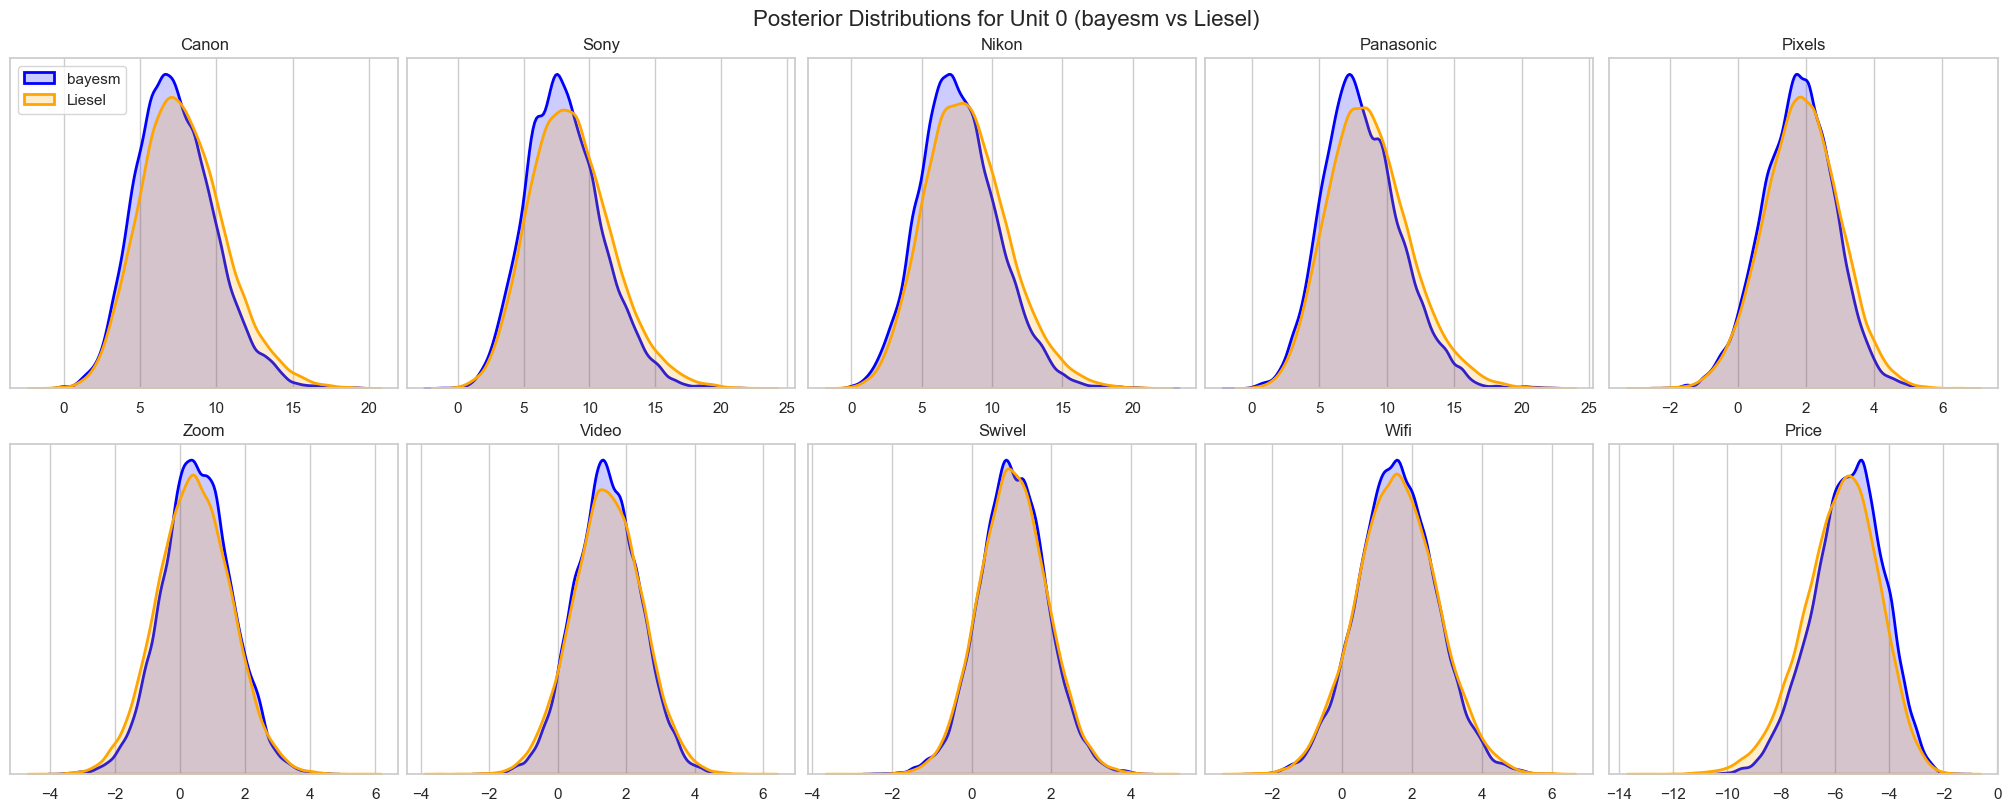

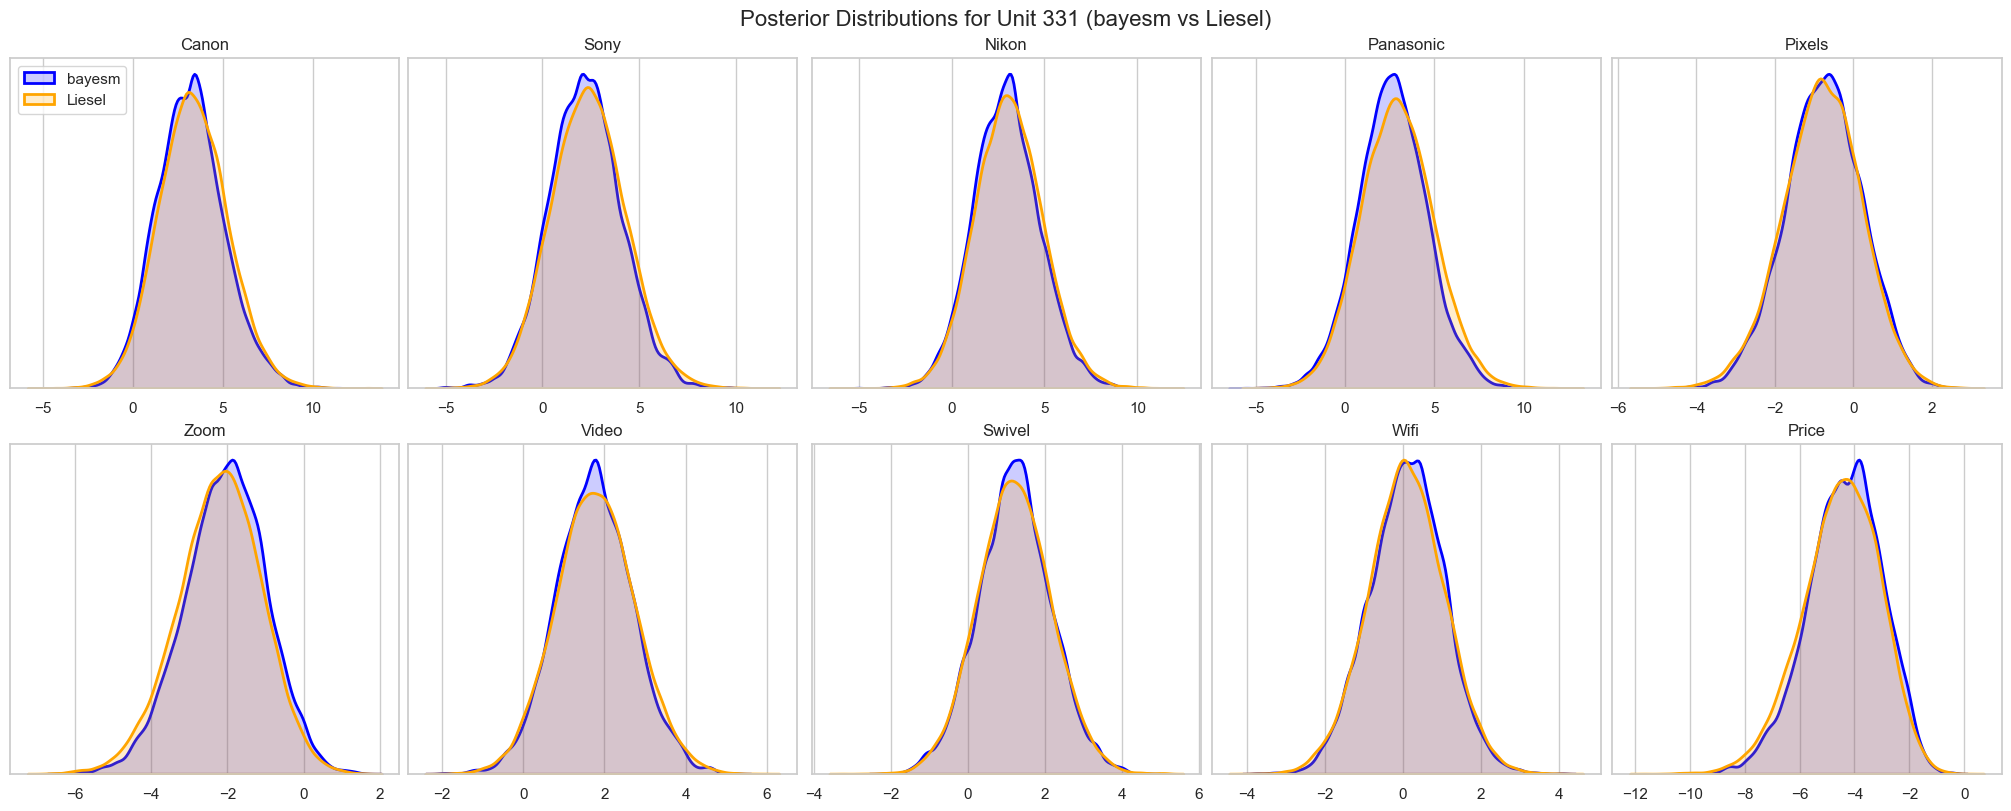

In [47]:
def plot_unit_comparison(unit_idx, r_data, liesel_data, param_names):
    """
    Plots a 2x5 grid of KDE plots comparing bayesm vs Liesel for a single unit.
    """
    fig, axes = plt.subplots(2, 5, figsize=(20, 8), constrained_layout=True)
    fig.suptitle(f'Posterior Distributions for Unit {unit_idx} (bayesm vs Liesel)', fontsize=16)
    
    axes = axes.flatten()
    
    for i, param in enumerate(param_names):
        ax = axes[i]
        
        # Extract data for this unit and parameter
        r_vals = r_data[:, unit_idx, i]
        liesel_vals = liesel_data[:, unit_idx, i]
        
        # Plot Density (KDE)
        sns.kdeplot(r_vals, ax=ax, color='blue', fill=True, alpha=0.2, label='bayesm', linewidth=2)
        sns.kdeplot(liesel_vals, ax=ax, color='orange', fill=True, alpha=0.2, label='Liesel', linewidth=2)
        
        # Aesthetics
        ax.set_title(f"{param}")
        ax.set_ylabel("") # Clean up y-axis labels
        ax.set_yticks([]) # Hide y-ticks
        
        # Legend only on the first plot
        if i == 0:
            ax.legend(loc='upper left')

    plt.show()


# Compare 2 Arbitrary Units (first and last index of 332 units)
# Plot for Unit 0 (First respondent)
plot_unit_comparison(0, beta_r_samples, beta_liesel_flat, param_names)

# Plot for Unit 100 (Arbitrary other respondent)
plot_unit_comparison(331, beta_r_samples, beta_liesel_flat, param_names)


Calculated R means. Shape: (332, 10)
Calculated Python means. Shape: (332, 10)


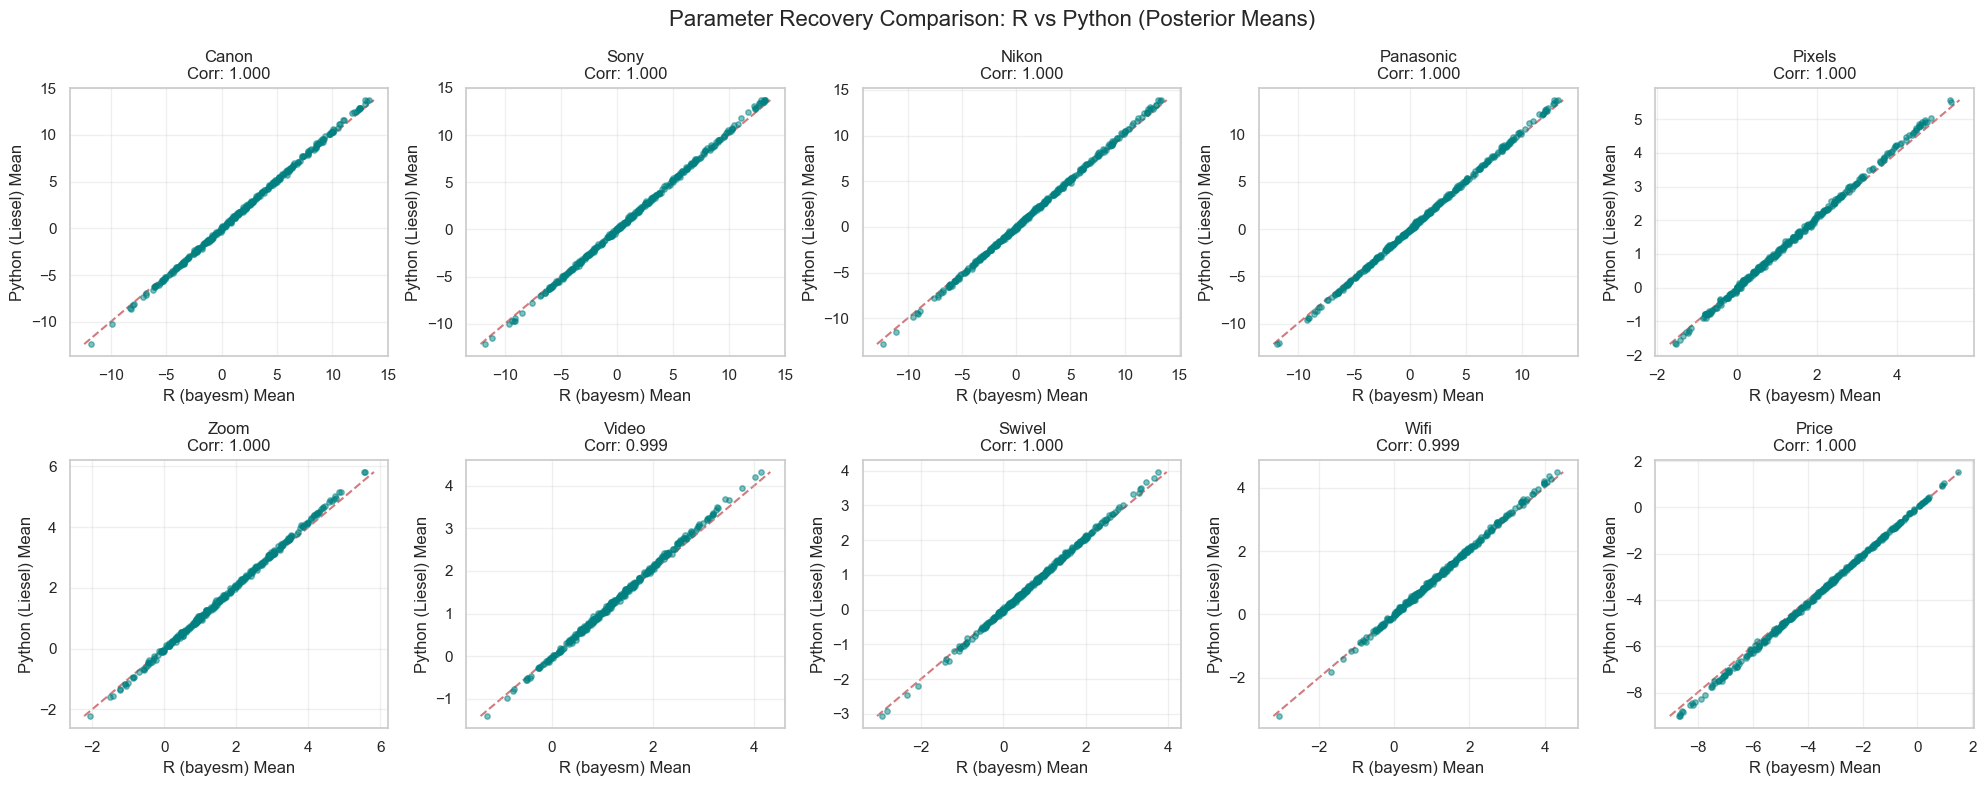

In [48]:
# Prepare Estimates (Calculate Means from Posteriors)
r_betas_mean = np.mean(beta_r_samples, axis=0)
print(f"Calculated R means. Shape: {r_betas_mean.shape}")

# Python (Liesel): Take mean over Chains (Axis 0) and Draws (Axis 1)
py_betas_mean = np.mean(samples["beta_i"], axis=(0, 1))
print(f"Calculated Python means. Shape: {py_betas_mean.shape}")

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, param in enumerate(param_names):
    ax = axes[i]
    
    # Extract the column for the specific parameter across all units
    x_val = r_betas_mean[:, i]   # R Means
    y_val = py_betas_mean[:, i]  # Python Means
    
    # Calculate Correlation
    corr = np.corrcoef(x_val, y_val)[0, 1]
    
    # Scatter plot
    ax.scatter(x_val, y_val, alpha=0.5, s=15, color='teal')
    
    # Diagonal reference line (Perfect match line)
    plot_min = min(np.min(x_val), np.min(y_val))
    plot_max = max(np.max(x_val), np.max(y_val))
    
    ax.plot([plot_min, plot_max], [plot_min, plot_max], 'r--', alpha=0.75, zorder=0, label='Identity Line')
    
    # Labels and Titles
    ax.set_title(f"{param}\nCorr: {corr:.3f}")
    ax.set_xlabel("R (bayesm) Mean")
    ax.set_ylabel("Python (Liesel) Mean")
    ax.grid(True, alpha=0.3)

plt.suptitle("Parameter Recovery Comparison: R vs Python (Posterior Means)", fontsize=16)
plt.tight_layout()
plt.show()

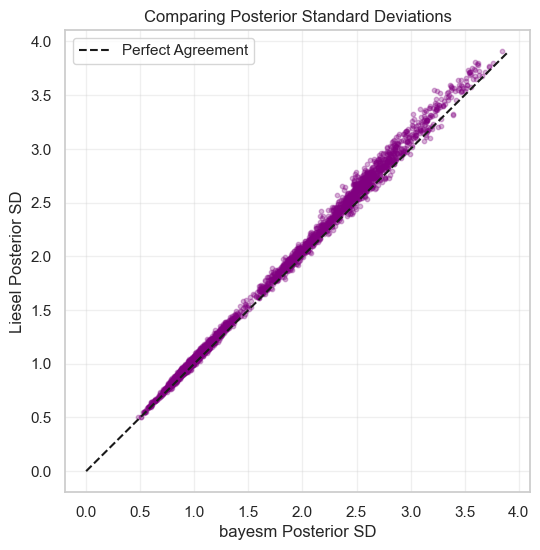

In [49]:
# Compute flattened SDs directly (Collapsing MCMC axes)
# R: (Draws, Units, Params) -> Mean across axis 0, then flatten
r_flat = np.std(beta_r_samples, axis=0).flatten()

# Python: (Chains, Draws, Units, Params) -> Mean across axes 0 & 1, then flatten
py_flat = np.array(samples["beta_i"].std(axis=(0, 1))).flatten()

# Plotting
plt.figure(figsize=(6, 6))
limit = max(r_flat.max(), py_flat.max())

plt.scatter(r_flat, py_flat, alpha=0.3, color='purple', s=10)
plt.plot([0, limit], [0, limit], 'k--', label="Perfect Agreement")

plt.xlabel("bayesm Posterior SD")
plt.ylabel("Liesel Posterior SD")
plt.title("Comparing Posterior Standard Deviations")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Compare distributions of individual parameters means

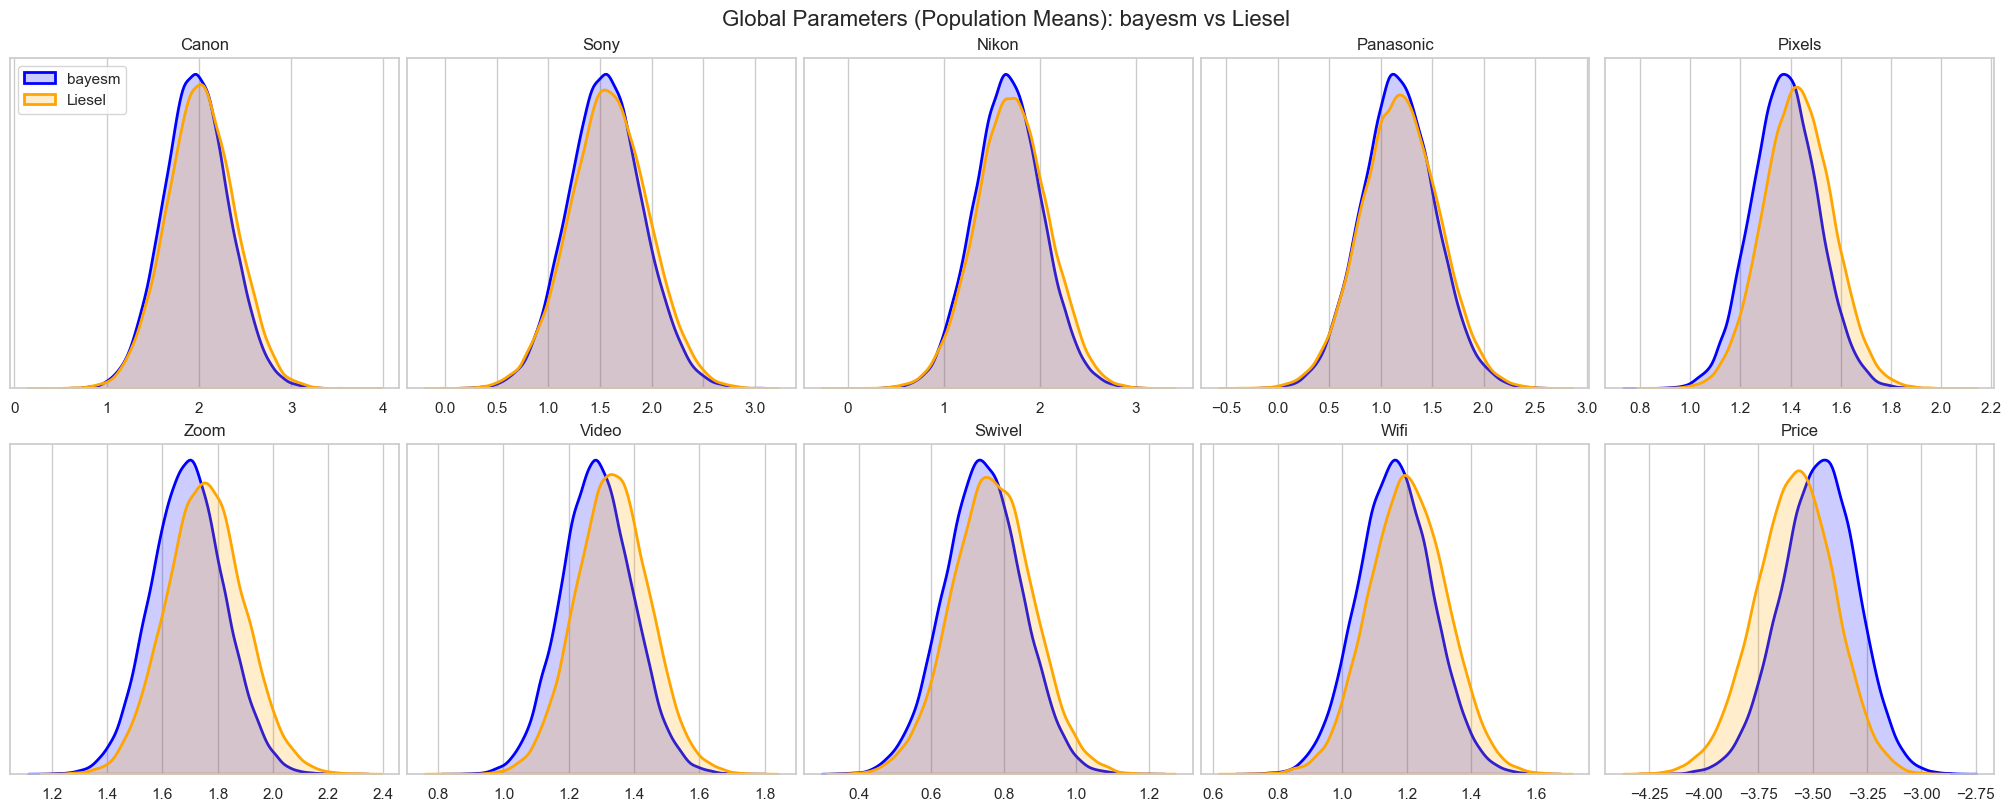

In [50]:
# Flatten Liesel Mu for comparison
# Current Shape: (Chains, Draws, Params) -> Target: (Total Draws, Params)
mu_liesel_flat = samples['mu'].reshape(-1, samples['mu'].shape[2])

def plot_global_comparison(r_mu, liesel_mu, param_names):
    fig, axes = plt.subplots(2, 5, figsize=(20, 8), constrained_layout=True)
    fig.suptitle('Global Parameters (Population Means): bayesm vs Liesel', fontsize=16)

    axes = axes.flatten()

    for i, param in enumerate(param_names):
        ax = axes[i]
        
        # Extract data for this parameter
        r_vals = r_mu[:, i]
        liesel_vals = liesel_mu[:, i]
        
        # Plot Density
        sns.kdeplot(r_vals, ax=ax, color='blue', fill=True, alpha=0.2, label='bayesm', linewidth=2)
        sns.kdeplot(liesel_vals, ax=ax, color='orange', fill=True, alpha=0.2, label='Liesel', linewidth=2)
        
        ax.set_title(f"{param}")
        ax.set_ylabel("")
        ax.set_yticks([])
        
        if i == 0:
            ax.legend(loc='upper left')

    plt.show()

plot_global_comparison(mu_r_samples, mu_liesel_flat, param_names)

In [51]:
def create_summary_table(r_mu, liesel_mu, param_names):
    # Calculate Statistics
    r_means = r_mu.mean(axis=0)
    l_means = liesel_mu.mean(axis=0)
    
    r_std = r_mu.std(axis=0)
    l_std = liesel_mu.std(axis=0)
    
    # Create DataFrame
    df = pd.DataFrame({
        'Parameter': param_names,
        'R_Mean': r_means,
        'Liesel_Mean': l_means,
        'Diff_Mean': r_means - l_means,
        'R_Std': r_std,
        'Liesel_Std': l_std
    })
    
    # Formatting for display
    return df.round(4)

# Generate and display
comparison_df = create_summary_table(mu_r_samples, mu_liesel_flat, param_names)
display(comparison_df)

,Parameter,R_Mean,Liesel_Mean,Diff_Mean,R_Std,Liesel_Std
0,Canon,1.9671,2.0156,-0.0485,0.3529,0.3707
1,Sony,1.5507,1.5854,-0.0347,0.3629,0.3820
2,Nikon,1.6670,1.7094,-0.0424,0.3566,0.3784
3,Panasonic,1.1691,1.1857,-0.0167,0.3585,0.3784
4,Pixels,1.3766,1.4286,-0.0520,0.1321,0.1381
5,Zoom,1.6912,1.7540,-0.0629,0.1320,0.1407
6,Video,1.2861,1.3335,-0.0474,0.1094,0.1125
7,Swivel,0.7418,0.7679,-0.0261,0.1072,0.1118
8,Wifi,1.1631,1.2027,-0.0396,0.1156,0.1214
9,Price,-3.4748,-3.5852,0.1105,0.1739,0.1824
